c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.0778 - loss: 3.0235

3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.0802 - loss: 3.0862 - val_accuracy: 0.1000 - val_loss: 2.3150
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.0703 - loss: 3.5927 - val_accuracy: 0.0500 - val_loss: 2.3459
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.0703 - loss: 3.3814 - val_accuracy: 0.0500 - val_loss: 2.3757
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.1021 - loss: 3.2377 - val_accuracy: 0.0500 - val_loss: 2.4099
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.0818 - loss: 3.1104 - val_accuracy: 0.1000 - val_loss: 2.4533
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.1859 - loss: 2.8128 - val_accuracy: 0.1000 - val_loss: 2.5050



Precisión en prueba: 0.1000
Pérdida en prueba: 2.3150
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step


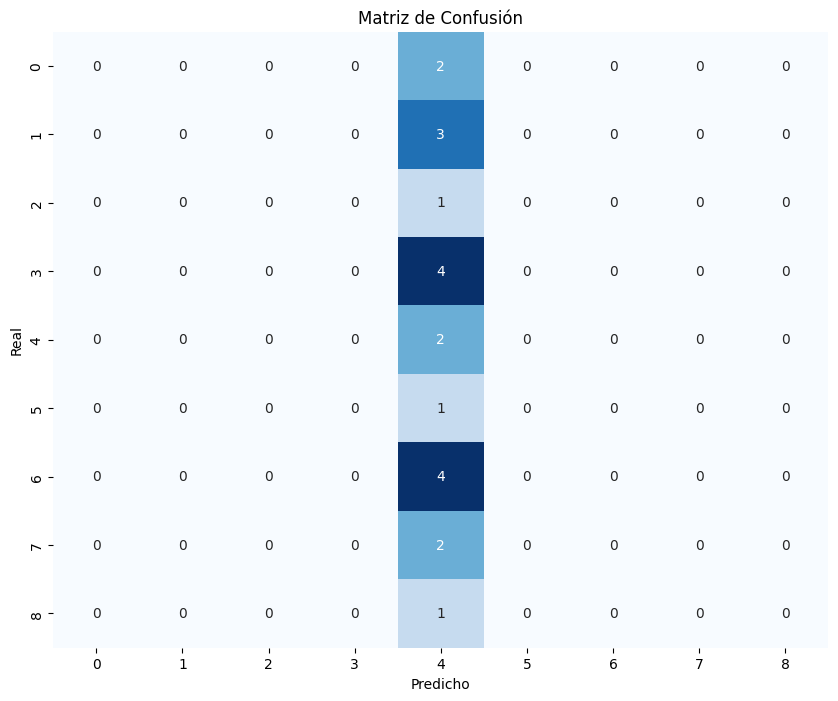

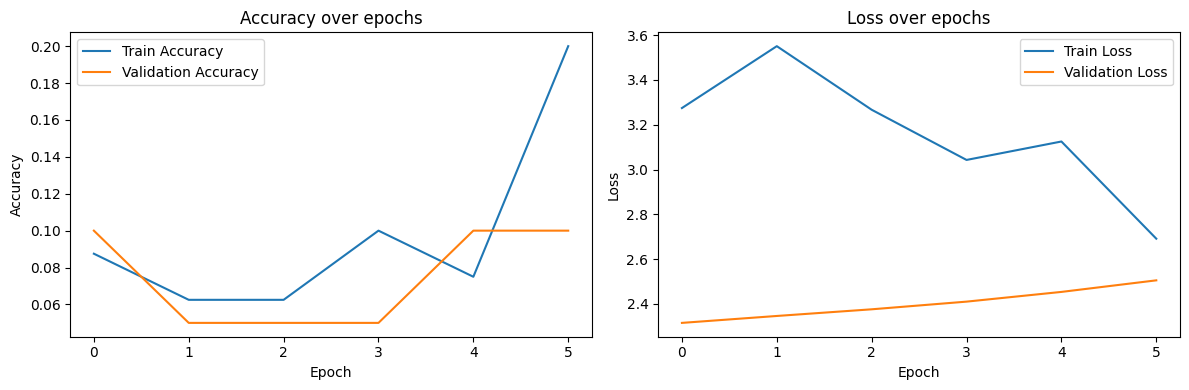

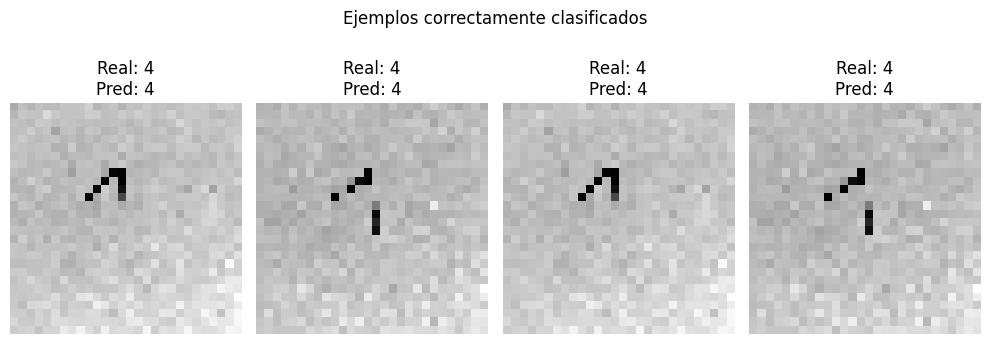

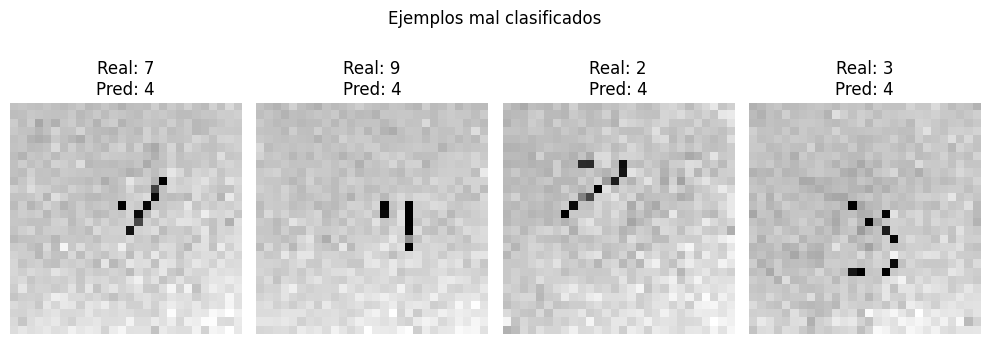

In [2]:
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Ruta del dataset
ruta_dataset = r"C:\Users\Lenovo\OneDrive\Documentos\IA_entrega_6\Dataseet"

# Listas para almacenar imágenes y etiquetas
imagenes = []
etiquetas = []

# Cargar las imágenes
for etiqueta in range(10):
    carpeta_digito = os.path.join(ruta_dataset, str(etiqueta))
    for imagen_nombre in os.listdir(carpeta_digito):
        if imagen_nombre.endswith(".jpg"):
            imagen = cv2.imread(os.path.join(carpeta_digito, imagen_nombre))
            if imagen is not None:
                imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
                imagen_redimensionada = cv2.resize(imagen_gris, (28, 28)) # CAMBIO A 28x28
                imagen_normalizada = imagen_redimensionada / 255.0

                imagenes.append(imagen_normalizada)
                etiquetas.append(etiqueta)

# Convertir a arrays de NumPy
imagenes = np.array(imagenes)
etiquetas = np.array(etiquetas)

# División en entrenamiento y prueba
imagenes_train, imagenes_test, etiquetas_train, etiquetas_test = train_test_split(
    imagenes, etiquetas, test_size=0.2, random_state=42)

# Expandir dimensiones
imagenes_train = np.expand_dims(imagenes_train, axis=-1)
imagenes_test = np.expand_dims(imagenes_test, axis=-1)

# One-hot encoding
etiquetas_train = to_categorical(etiquetas_train, 10)
etiquetas_test = to_categorical(etiquetas_test, 10)

# Aumento de datos
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1)
datagen.fit(imagenes_train)

# Crear modelo profundo de 30 capas
modelo = Sequential()

# Primera capa (necesita input_shape)
modelo.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
modelo.add(BatchNormalization())

# Agregar más capas
for _ in range(14): # 14 bloques de Conv2D + BatchNorm
    modelo.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    modelo.add(BatchNormalization())

# MaxPooling
modelo.add(MaxPooling2D(pool_size=(2, 2)))
modelo.add(Dropout(0.25))

# Segundo bloque de convoluciones
for _ in range(14): # 14 bloques de Conv2D + BatchNorm
    modelo.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    modelo.add(BatchNormalization())

# Segundo MaxPooling
modelo.add(MaxPooling2D(pool_size=(2, 2)))
modelo.add(Dropout(0.25))

# Flatten y Dense
modelo.add(Flatten())
modelo.add(Dense(128, activation='relu'))
modelo.add(BatchNormalization())
modelo.add(Dropout(0.5))
modelo.add(Dense(10, activation='softmax'))

# Compilación del modelo
optimizer = Adam(learning_rate=0.001)
modelo.compile(optimizer=optimizer,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

# Entrenamiento
history = modelo.fit(datagen.flow(imagenes_train, etiquetas_train, batch_size=32),
                     epochs=50,
                     validation_data=(imagenes_test, etiquetas_test),
                     callbacks=callbacks)

# Cargar mejor modelo
modelo = tf.keras.models.load_model('best_model.h5')

# Evaluar
test_loss, test_acc = modelo.evaluate(imagenes_test, etiquetas_test, verbose=0)
print(f"\nPrecisión en prueba: {test_acc:.4f}")
print(f"Pérdida en prueba: {test_loss:.4f}")

# Matriz de confusión
y_pred = np.argmax(modelo.predict(imagenes_test), axis=1)
y_true = np.argmax(etiquetas_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# Gráficas de entrenamiento
def plot_results(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_results(history)

# Visualización de ejemplos
def plot_examples(images, true_labels, pred_labels, num_examples=4, title=""):
    indices = np.random.choice(range(len(images)), num_examples)
    plt.figure(figsize=(10, 4))
    plt.suptitle(title)
    for i, idx in enumerate(indices):
        plt.subplot(1, num_examples, i+1)
        plt.imshow(images[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Real: {true_labels[idx]}\nPred: {pred_labels[idx]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Ejemplos correctos
correct_idx = np.where(y_pred == y_true)[0]
plot_examples(imagenes_test[correct_idx], 
              y_true[correct_idx], 
              y_pred[correct_idx],
              title="Ejemplos correctamente clasificados")

# Ejemplos incorrectos
incorrect_idx = np.where(y_pred != y_true)[0]
plot_examples(imagenes_test[incorrect_idx], 
              y_true[incorrect_idx], 
              y_pred[incorrect_idx],
              title="Ejemplos mal clasificados")
